# Spatially Variable Ice and Firn Fields

This notebook introduces a prior model for ice and firn thickness change in which variability is concentrated near physically plausible melt regions.

We begin with a uniform baseline, then construct spatially varying pointwise standard-deviation fields from present-day ice thickness. These fields are used to shape Gaussian priors for ice and firn, producing realistic stochastic samples of thickness and load change.

## Uniform Ice Field

As a reference model, we first consider a uniform spatial weighting over the ice mask. This corresponds to a rotationally invariant prior over the ice sheet domain: smooth random fields are generated, but no sub-region is preferred a priori.

This baseline is useful because it isolates the effect of the covariance length scale from any geography-dependent weighting.

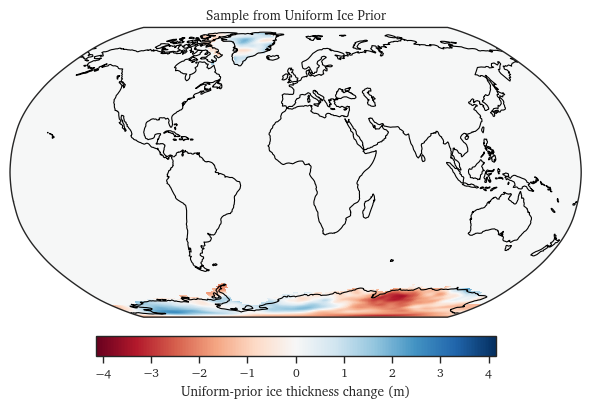

In [19]:
import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np

from pyslfp import FingerPrint, IceModel
from pyslfp_extras.ice_thickness import IceSheetChange
from pyslfp_extras.plotting import plot
from project import colors

np.random.seed(423991)

lmax = 256
fp = FingerPrint(lmax=lmax)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

ice_change_uniform = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=0.01 * fp.mean_sea_floor_radius,
    pattern=IceSheetChange.UniformPattern(),
    include_firn=False,
    ice_gmsl_std=0.02,
)

uniform_sample = ice_change_uniform.sample()

fig, ax, _ = plot(
    uniform_sample.ice_thickness,
    symmetric=True,
    colorbar_label="Uniform-prior ice thickness change (m)",
)
ax.set_title("Sample from Uniform Ice Prior")
plt.show()

## Spatial Variability from Present-Day Ice Thickness

A uniform prior does not reflect the strong spatial heterogeneity of melt processes. In practice, melt-related variability is typically larger near ice margins and smaller in thick interior regions.

We encode this by mapping present-day ice thickness to a smooth activator field using a generalized logistic function. If $x$ is standardized thickness, the activator is

$$
a(x)=a_0+\frac{a_1-a_0}{\left(1+\exp\left[b(x-m)\right]\right)^{1/\nu}},
$$

where $a_0, a_1$ are lower and upper asymptotes, $b$ controls steepness, $m$ is the threshold location, and $\nu$ controls asymmetry.

In this notebook, ice and firn variability are treated as complementary fields:

- ice multiplier: $a(x)$
- firn multiplier: $1-a(x)$

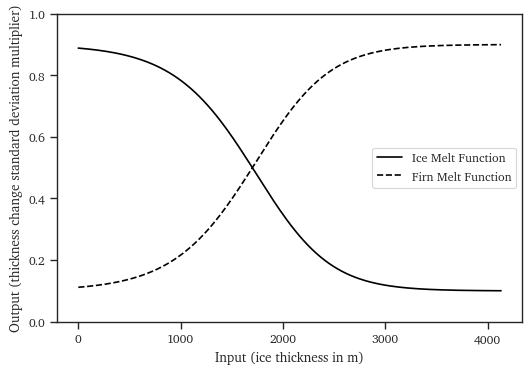

In [20]:
# Activator used by ThicknessWeightedPattern


def activator_richards(
    x,
    x_min,
    x_max,
    lower_asymptote=0.1,
    upper_asymptote=0.9,
    steepness=10.0,
    threshold=0.45,
    asymmetry=0.75,
):
    x_std = (x - x_min) / (x_max - x_min)
    return lower_asymptote + (
        upper_asymptote - lower_asymptote
    ) / (1 + np.exp(steepness * (x_std - threshold))) ** (
        1 / asymmetry
    )


thickness_data = fp.ice_thickness.data
thickness_data = thickness_data[thickness_data > 0]
x_line = np.linspace(
    thickness_data.min(), thickness_data.max(), 200
)
ice_multiplier = activator_richards(
    x_line, thickness_data.min(), thickness_data.max()
)
firn_multiplier = 1 - ice_multiplier

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    x_line,
    ice_multiplier,
    label="Ice Melt Function",
    color="black",
)
ax.plot(
    x_line,
    firn_multiplier,
    label="Firn Melt Function",
    color="black",
    linestyle="dashed",
)
ax.set_xlabel("Input (ice thickness in m)")
ax.set_ylabel(
    "Output (thickness change standard deviation multiplier)"
)
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.show()

The activator can be evaluated on the present-day thickness field to obtain pointwise prior scaling fields for ice and firn. These fields control the local standard deviation of the latent melt-driven thickness process.

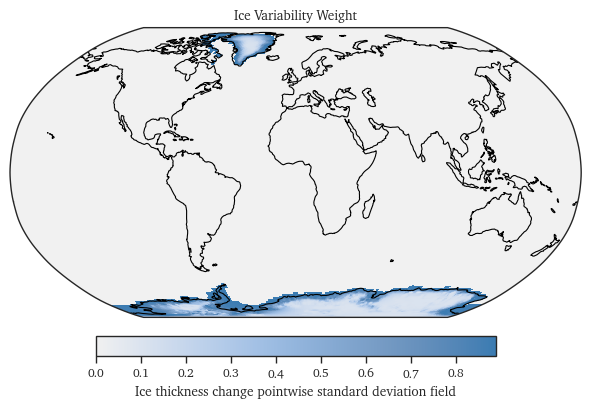

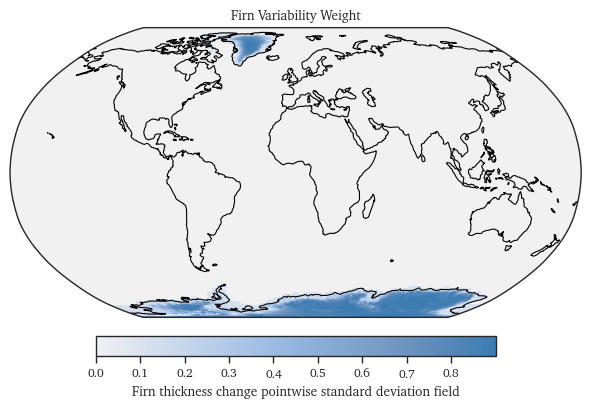

In [21]:
weighted_pattern = IceSheetChange.ThicknessWeightedPattern(
    lower_asymptote=0.1,
    upper_asymptote=0.9,
    steepness=10.0,
    threshold=0.45,
    asymmetry=0.75,
)

ice_std_field = weighted_pattern.spatial_weights(fp)
firn_std_field = weighted_pattern.firn_weights(fp)

fig, ax, _ = plot(
    ice_std_field,
    cmap=cc.cm.blues,
    colorbar_label="Ice thickness change pointwise standard deviation field",
)
ax.set_title("Ice Variability Weight")
plt.show()

fig, ax, _ = plot(
    firn_std_field,
    cmap=cc.cm.blues,
    colorbar_label="Firn thickness change pointwise standard deviation field",
)
ax.set_title("Firn Variability Weight")
plt.show()

With these spatially varying multipliers, we construct a joint ice-firn prior and draw samples of thickness change. The same physical setup is used later to generate load, fingerprint, and SSH realizations.

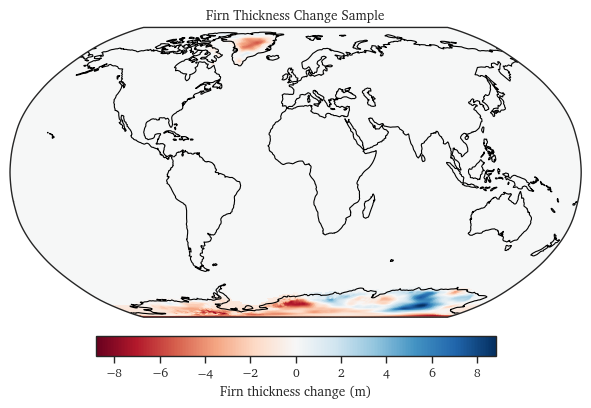

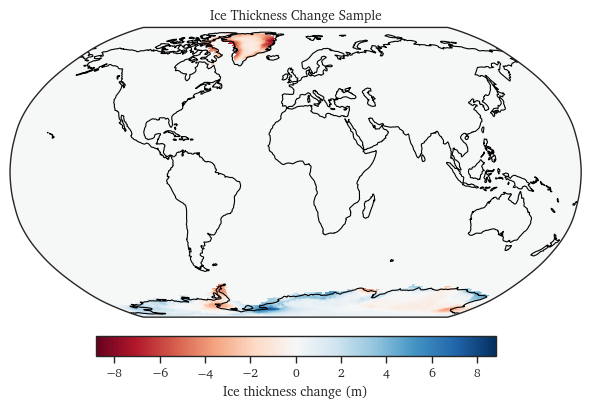

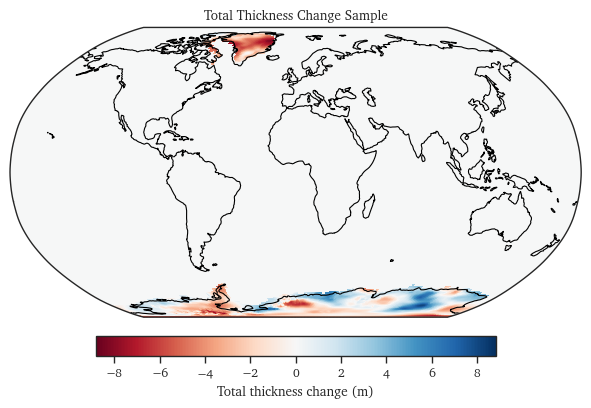

In [22]:
ice_change_spatial = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=0.01 * fp.mean_sea_floor_radius,
    pattern=weighted_pattern,
    ice_gmsl_std=0.02,
    firn_gmsl_std=0.015,
    include_firn=True,
    ice_density=fp.ice_density,
    firn_density=0.3 * fp.ice_density,
)

samples = ice_change_spatial.sample()

thickness_max = np.max(
    [
        np.abs(samples.firn_thickness).max(),
        np.abs(samples.ice_thickness).max(),
        np.abs(samples.total_thickness).max(),
    ]
)

fig, ax, _ = plot(
    samples.firn_thickness,
    vmax=thickness_max,
    vmin=-thickness_max,
    colorbar_label="Firn thickness change (m)",
)
ax.set_title("Firn Thickness Change Sample")
plt.show()

fig, ax, _ = plot(
    samples.ice_thickness,
    vmax=thickness_max,
    vmin=-thickness_max,
    colorbar_label="Ice thickness change (m)",
)
ax.set_title("Ice Thickness Change Sample")
plt.show()

fig, ax, _ = plot(
    samples.total_thickness,
    vmax=thickness_max,
    vmin=-thickness_max,
    colorbar_label="Total thickness change (m)",
)
ax.set_title("Total Thickness Change Sample")
plt.show()

These realizations induce corresponding spatially variable load fields through density scaling.

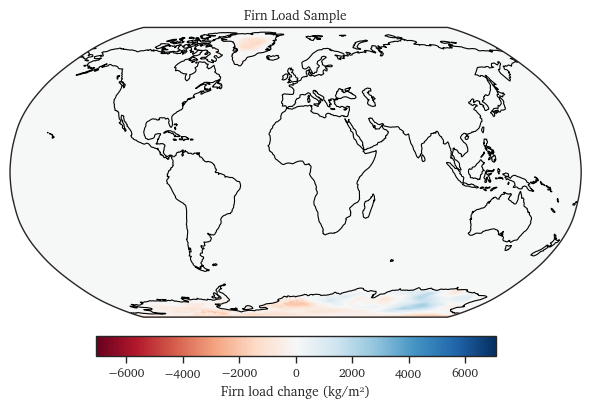

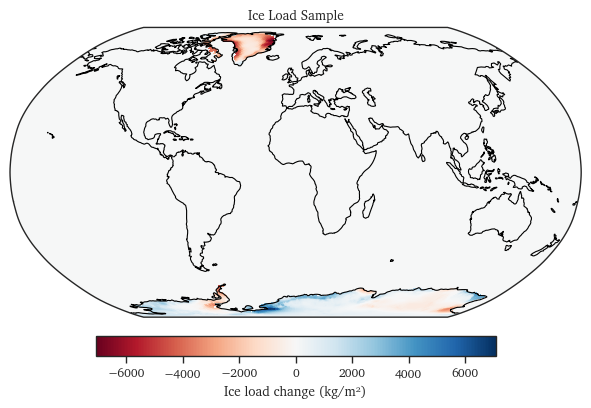

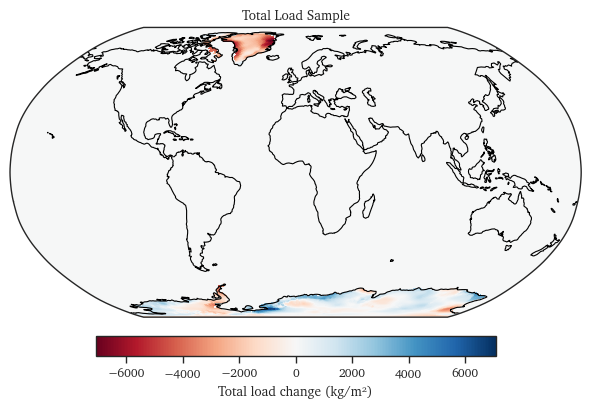

In [23]:
load_max = np.max(
    [
        np.abs(samples.firn_load).max(),
        np.abs(samples.ice_load).max(),
        np.abs(samples.total_load).max(),
    ]
)

fig, ax, _ = plot(
    samples.firn_load,
    vmax=load_max,
    vmin=-load_max,
    colorbar_label="Firn load change (kg/m²)",
)
ax.set_title("Firn Load Sample")
plt.show()

fig, ax, _ = plot(
    samples.ice_load,
    vmax=load_max,
    vmin=-load_max,
    colorbar_label="Ice load change (kg/m²)",
)
ax.set_title("Ice Load Sample")
plt.show()

fig, ax, _ = plot(
    samples.total_load,
    vmax=load_max,
    vmin=-load_max,
    colorbar_label="Total load change (kg/m²)",
)
ax.set_title("Total Load Sample")
plt.show()